# Naive Bayes Classification to Predict Titanic Survival

**Deep Dive Coding Data Science Bootcamp Sample Project**

---
Robert Citek - October 5th, 2026


## Problem Definition

State the business problem. Translate the business problem into a Data Science problem by stating what kind of problem it is ( supervised vs unsupervised ) and whether it is a classification, regression, or clustering problem.  Mention which model will be used, if known.

We would like to tell a passenger on the Titanic whether or not they will survive. The target column is 'Survived', which is a binary field. Hence, this is a supervised, binary classification problem, and we will be using a Gaussian Naive Bayes model to analyze the data.

In [1]:
# This is a supervised binary classification problem, using a Gaussian Naive Bayes model.

## Data Collection/Sources

### Data Overview

This data comes from [Kaggle](https://www.kaggle.com/c/titanic/data), which was then copied to AWS for easy access.

https://ddc-datascience.s3.amazonaws.com/Projects/Example/Data/Titanic.train.csv


### Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn import metrics
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

### File Paths

Create a variable `url` that contains the web link to the CSV data

In [3]:
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Example/Data/Titanic.train.csv'    # insert url here
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Example/Data/Titanic.train.csv'

### Load data

Load the data into a data frame named `titanic_df`.

In [4]:
# load data
titanic_df = pd.read_csv(url)
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### head

Look at the first few rows

In [5]:
# first few rows
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### tail

Look at the last few rows


In [6]:
# last few rows
titanic_df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### shape


In [7]:
# shape of data frame
titanic_df.shape

(891, 12)

### size


In [8]:
# size of data frame
titanic_df.size

10692

### Summary meta-data

Run the `info()` method on the data frame.


In [9]:
# display meta-data
titanic_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Summary statistics

Summary statistics give you a quick overview of the data.  Some items to spot check:
- the Target:
  - look for nulls
    - null will be culled
  - look at min, max, median, and mean
    - is it a categorical field masquerading as a number?
- the Features:
  - numerical
    - look at min, max, median, and mean
      - a min=1 and max=count suggests an ID
  - categorical
    - look at unique and freq
      - freq=1, unique=count suggests an ID
      - freq=count suggests a meaningless feature

Run the `describe()` method on the data frame.

In [10]:
# display summary statistics
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### target value_counts()


The target should be the first field that you look at.  Its data type will tell you what kind of machine learning problem this is ( classification or regression. ) Any nulls should be culled.  You can check for any skew in the data set.

In [11]:
# value_counts on target ; include nulls
titanic_df['Survived'].value_counts(dropna=False)

,count
Survived,
0,549
1,342


In [12]:
# normalized value_counts on target ; include nulls
titanic_df['Survived'].value_counts(normalize=True, dropna=False) * 100


,proportion
Survived,
0,61.616162
1,38.383838


### Nulls



In [13]:
# look for nulls
titanic_df.isnull().sum().sort_values(ascending=False)

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


In [14]:
type(titanic_df.isnull().sum().sort_values(ascending=False))

pandas.core.series.Series

In [15]:
# look for nulls, displaying relative frequency
null_sums  = titanic_df.isnull().sum()
totals     = titanic_df.shape[0]
null_freqs = null_sums / totals * 100

null_freqs.sort_values(ascending=False)

,0
Cabin,77.104377
Age,19.865320
Embarked,0.224467
PassengerId,0.000000
Name,0.000000
Pclass,0.000000
Survived,0.000000
Sex,0.000000
Parch,0.000000
SibSp,0.000000


In [16]:
rel_freq = titanic_df.isnull().mean().sort_values(ascending=False) * 100 # trick to use with binary data set
rel_freq

,0
Cabin,77.104377
Age,19.865320
Embarked,0.224467
PassengerId,0.000000
Name,0.000000
Pclass,0.000000
Survived,0.000000
Sex,0.000000
Parch,0.000000
SibSp,0.000000


### dtypes - column data types

Which data types would be appropriate for Gaussian Naive Bayes?


In [17]:
# display data types
titanic_df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [18]:
type(titanic_df.dtypes)

pandas.core.series.Series

### Unique elements


If the total number of unique items in a field equals the number of rows, that suggests those fields are unique IDs ( e.g. names, IDs ) and should be dropped.


In [19]:
# number of unique elements in a column
titanic_df.nunique(axis='rows').sort_values(ascending=False)

,0
PassengerId,891
Name,891
Ticket,681
Fare,248
Cabin,147
Age,88
SibSp,7
Parch,7
Embarked,3
Pclass,3


## Data Cleaning


### Backup #1


In [20]:
# make backup
titanic_df_bak = titanic_df.copy()
titanic_df_bak

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [21]:
# restore from backup
titanic_df = titanic_df_bak.copy()
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### Keep only the target and one feature

Select `Survived` for the target and `Age` for the single feature

In [22]:
# select the target and one feature
titanic_df[['Survived', 'Age']]

,Survived,Age
0,0,22.0
1,1,38.0
2,1,26.0
3,1,35.0
4,0,35.0
...,...,...
886,0,27.0
887,1,19.0
888,0,NaN
889,1,26.0


In [23]:
titanic_df = titanic_df[['Survived', 'Age']]
titanic_df

,Survived,Age
0,0,22.0
1,1,38.0
2,1,26.0
3,1,35.0
4,0,35.0
...,...,...
886,0,27.0
887,1,19.0
888,0,NaN
889,1,26.0


In [24]:
titanic_df

,Survived,Age
0,0,22.0
1,1,38.0
2,1,26.0
3,1,35.0
4,0,35.0
...,...,...
886,0,27.0
887,1,19.0
888,0,NaN
889,1,26.0


### Backup #2


In [25]:
# make backup
titanic_df_bak_2 = titanic_df.copy()
titanic_df_bak_2

,Survived,Age
0,0,22.0
1,1,38.0
2,1,26.0
3,1,35.0
4,0,35.0
...,...,...
886,0,27.0
887,1,19.0
888,0,NaN
889,1,26.0


In [26]:
# restore from backup
titanic_df = titanic_df_bak_2.copy()
titanic_df

,Survived,Age
0,0,22.0
1,1,38.0
2,1,26.0
3,1,35.0
4,0,35.0
...,...,...
886,0,27.0
887,1,19.0
888,0,NaN
889,1,26.0


### Address any rows with nulls

- If the number of nulls in a column is low, it would be easiest to drop the row.
- If the number of nulls in a column is high, it would be easiest to drop the column.
- If the number of nulls in a column is between the low and high, one should impute values for the nulls.


#### Impute

Impute with the median.


In [27]:
# Calculate the median
titanic_median = titanic_df['Age'].median()
titanic_median

28.0

In [28]:
# Assign median to nulls
# titanic_df['Age'].fillna( value = titanic_median, inplace = True ) # old way
titanic_df.fillna({'Age': titanic_median}, inplace=True)
titanic_df

,Survived,Age
0,0,22.0
1,1,38.0
2,1,26.0
3,1,35.0
4,0,35.0
...,...,...
886,0,27.0
887,1,19.0
888,0,28.0
889,1,26.0


In [29]:
# Verify there are no nulls
titanic_df.isnull().sum()

,0
Survived,0
Age,0


In [30]:
# Verify median is about the same as before
titanic_df['Age'].median()

28.0

## Exploratory Data Analysis


GNB has two requirements:
1. the features are normally distributed
1. the features are not correlated with each other





### normal distribution of features: histogram


array([[<Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Age'}>]], dtype=object)

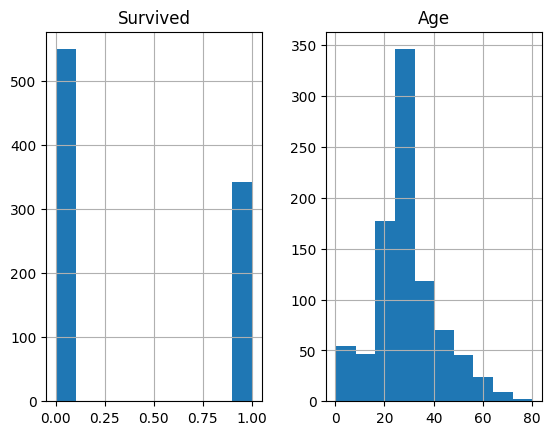

In [31]:
# Display a histogram
titanic_df.hist()

### no correlation with single feature



## Processing



In [32]:
# Split data frame into target and features
#target = titanic_df['Survived']
#features = titanic_df[['Age']]

target_col = 'Survived'
target = titanic_df[ target_col ]
# features = titanic_df.drop(labels = [ target_col ], axis='columns')
features = titanic_df.drop( columns = [ target_col ] )

In [33]:
# Verify features
features

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,28.0
889,26.0


In [34]:
features.shape

(891, 1)

In [35]:
# Verify target
target

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [36]:
target.shape

(891,)

In [37]:
target.ndim

1

In [38]:
features.ndim

2

### Single Cross Validation ( CV )

Run a single Cross Validation

#### Train Test Split

In [39]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split( features, target, test_size = 0.25 )

In [40]:
# Verify shape of each data set from Train Test Split
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((668, 1), (223, 1), (668,), (223,))

In [41]:
for x in (X_train, X_test, y_train, y_test):
  print(x.shape)

(668, 1)
(223, 1)
(668,)
(223,)


#### Model


In [42]:
# Create an empty GNB model
modelGNB = GaussianNB()

#### Fit



In [43]:
# Train ( fit ) the model
modelGNB.fit(X_train, y_train)

GaussianNB()

#### Prediction


In [44]:
# Make predicitons using the model
results = modelGNB.predict(X_test)
results * 100

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0, 100,   0,   0,   0,   0,   0,   0,   0,   0,   0, 100,
         0,   0,   0, 100,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0, 100,   0,   0,   0,   0,   0, 100,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0, 100,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0, 100,   0,   0,   0, 10

#### Performance


We'll meassure accuracy, which is the proportions of the number correctly predicted, which is mathematically the same as one minus the proportion incorrectly predicted.

In [45]:
# Calculate the accuracy
accuracy = metrics.accuracy_score(y_test, results)
accuracy

0.6412556053811659

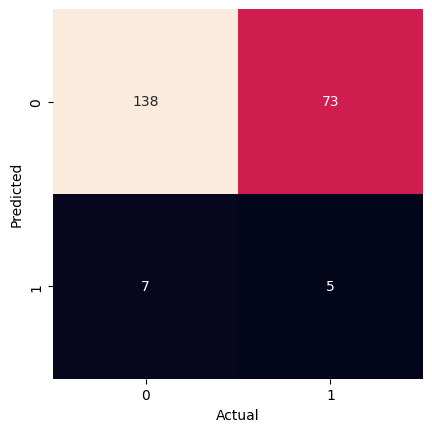

In [46]:
# Display a confusion matrix
matrix = metrics.confusion_matrix(y_test,results)
sns.heatmap(matrix.T,
  square=True,
  annot=True,
  fmt='d',
  cbar=False,
  # xticklabels=dataset.target_names,
  # yticklabels=dataset.target_names
)
plt.xlabel('Actual')
plt.ylabel('Predicted');

### Multiple Cross Validation ( CV )

Create a CV loop with 100 iterations.  Capture performance metric in an array names `results`.
Use accuracy for the performance metric.


In [51]:
n = 1_000
results = np.zeros(n)

# Multiple CV loop
for i in range(n):

  # Train Test Split
  X_train, X_test, y_train, y_test = train_test_split( features, target, test_size = 0.25 )

  # Create an empty GNB model
  modelGNB = GaussianNB()

  # Train ( fit ) the model
  modelGNB.fit(X_train, y_train)

  # Make predicitons using the model
  y_pred = modelGNB.predict(X_test)

  # Calculate the accuracy
  results[i] = metrics.accuracy_score(y_test, y_pred)

results

array([0.64125561, 0.67713004, 0.55156951, 0.61434978, 0.62780269,
       0.64125561, 0.60986547, 0.60538117, 0.65022422, 0.59192825,
       0.632287  , 0.6367713 , 0.60089686, 0.61883408, 0.60986547,
       0.60089686, 0.60986547, 0.66816143, 0.64573991, 0.57847534,
       0.632287  , 0.70403587, 0.66367713, 0.60986547, 0.64573991,
       0.68161435, 0.632287  , 0.61883408, 0.60986547, 0.61883408,
       0.61883408, 0.59192825, 0.60089686, 0.61883408, 0.66816143,
       0.61883408, 0.60986547, 0.65470852, 0.58295964, 0.61883408,
       0.64573991, 0.6367713 , 0.60986547, 0.6367713 , 0.65919283,
       0.65919283, 0.59192825, 0.59192825, 0.65470852, 0.61883408,
       0.64125561, 0.61883408, 0.632287  , 0.57399103, 0.61434978,
       0.57399103, 0.60986547, 0.632287  , 0.66367713, 0.58744395,
       0.62780269, 0.67713004, 0.66367713, 0.62780269, 0.62780269,
       0.59192825, 0.65022422, 0.67713004, 0.58744395, 0.64573991,
       0.61434978, 0.61434978, 0.65919283, 0.59192825, 0.63677

In [52]:
# Calculate mean of results
results.mean()

np.float64(0.6204753363228699)

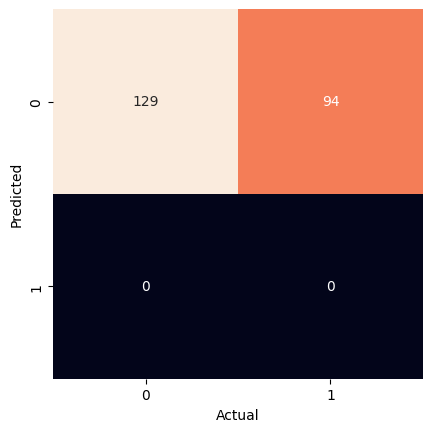

In [53]:
# Display a confusion matrix
matrix = metrics.confusion_matrix(y_test,y_pred)
sns.heatmap(matrix.T,
  square=True,
  annot=True,
  fmt='d',
  cbar=False,
  # xticklabels=dataset.target_names,
  # yticklabels=dataset.target_names
)
plt.xlabel('Actual')
plt.ylabel('Predicted');

<Axes: >

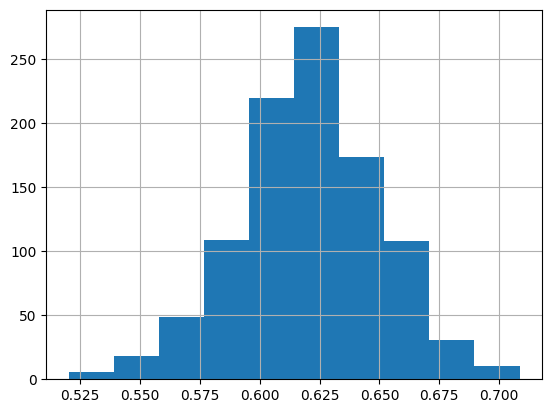

In [54]:
# Display a histogram of the results
pd.Series(results).hist()

## Communication of Results

Conclusion:

- Lots of false negatives using Age as a predictor
- Why? our dataset has more 0s than 1s! We have an unbalanced
dataset with more negatives than positives
- Data is trained to predict 0 (false Survived) over 1 (true)
- Accuracy is only 62% on average, suggesting age is not a good predictor of survival.
- Reasonably good distribution of results, suggesting mostly homogeneous population.

Future work:

- Add in more features, e.g. Fare
- balance data set
- use other (more sophisticated?) classification methods,    e.g. Random Forest

